In [1]:
%pip install scikit-learn

  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 98.1 kB/s  0:01:15m eta 0:00:02
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Machine Learning :

# Supervized Learning

## Regression

In [4]:
#libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, RidgeCV, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing



In [5]:
#data
boston = fetch_california_housing()
boston_df=pd.DataFrame(boston.data,columns=boston.feature_names)
#target variable
boston_df['Price']=boston.target

In [6]:
features = boston_df.columns[0:11]
target = boston_df.columns[-1]

#X and y values
X = boston_df[features].values
y = boston_df[target].values

#splot
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=17)

print("The dimension of X_train is {}".format(X_train.shape))
print("The dimension of X_test is {}".format(X_test.shape))
#Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

The dimension of X_train is (14448, 9)
The dimension of X_test is (6192, 9)


### Linear Regression

Coefficients: [ 3.69465466e-17  3.56804073e-17  8.33481119e-19  6.78625469e-16
 -2.47519756e-16  4.26473032e-16 -5.22069048e-16 -4.21474975e-16
  1.15736809e+00]
Intercept: 2.0728061254152608
Metadata Routing: {'fit': {'sample_weight': None}, 'score': {'sample_weight': None}}
Parameters: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}
Score: 1.0
Mean Squared Error: 5.915648097643473e-31
R-squared: 1.0
    Actual  Predicted
0  2.38800    2.38800
1  1.08800    1.08800
2  0.72700    0.72700
3  5.00001    5.00001
4  3.99200    3.99200
5  1.93700    1.93700
6  0.96600    0.96600
7  0.64800    0.64800
8  2.18400    2.18400
9  1.70000    1.70000


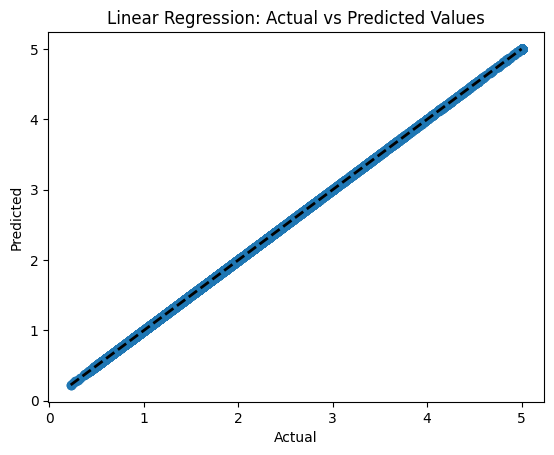

In [9]:
#linear model is a regression model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LinearRegression

linear_regression_model = LinearRegression(
    fit_intercept=True,  # Calculate y-intercept
    copy_X=True,         # Make a copy of X
    n_jobs=None,         # Use single core (default)
    positive=False       # Allow negative coefficients
)
linear_regression_model.fit(X_train, y_train, sample_weight=None)  # training the model
# Get the model coefficients (weights for each feature)
coefficients = linear_regression_model.coef_
print("Coefficients:", coefficients)

# Get the intercept (bias term)
intercept = linear_regression_model.intercept_
print("Intercept:", intercept)

# Get metadata routing 
metadata = linear_regression_model.get_metadata_routing()
print("Metadata Routing:", metadata)

#Get parameters for this estimator
parameters = linear_regression_model.get_params()
print("Parameters:", parameters)

#predict the target values for the test set
y_pred = linear_regression_model.predict(X_test)

# get score of the model
score = linear_regression_model.score(X_test, y_test)
print("Score:", score)

# Calculate Mean Squared Error
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# Calculate R-squared
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

# Display predictions vs actual values
import pandas as pd
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results.head(10))

# Plot results
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression: Actual vs Predicted Values')
plt.show()



### Ridge Regression

Coefficients: [ 1.44668487e-04  2.20431103e-05 -4.52642714e-05  5.15425125e-05
  4.16508084e-07 -7.52747560e-06 -1.60396743e-04 -1.55193732e-04
  1.15716474e+00]
Intercept: 2.0728061254152608
Metadata Routing: {'fit': {'sample_weight': None}, 'score': {'sample_weight': None}}
Parameters: {'alpha': 1.0, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}
Score: 0.9999999878080689
Mean Squared Error: 1.600628104217115e-08
R-squared: 0.9999999878080689
    Actual  Predicted
0  2.38800   2.388090
1  1.08800   1.087977
2  0.72700   0.727124
3  5.00001   4.999620
4  3.99200   3.991950
5  1.93700   1.937119
6  0.96600   0.966081
7  0.64800   0.648075
8  2.18400   2.183894
9  1.70000   1.700120
Feature coefficients: [ 1.44668487e-04  2.20431103e-05 -4.52642714e-05  5.15425125e-05
  4.16508084e-07 -7.52747560e-06 -1.60396743e-04 -1.55193732e-04
  1.15716474e+00]
Intercept: 2.0728061254152608


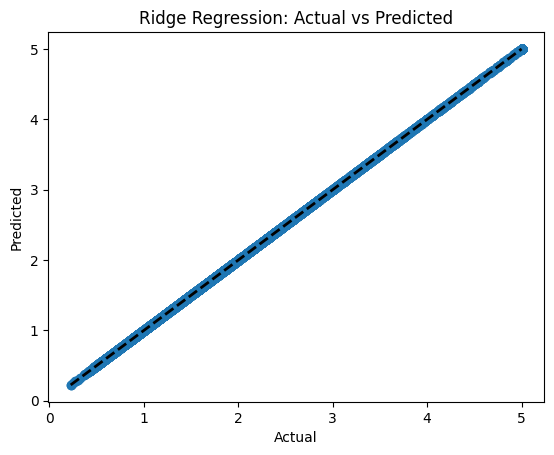

In [10]:
# Ridge regression is a linear regression method that uses L2 regularization to prevent overfitting.
# It adds a penalty equal to the square of the magnitude of coefficients.
# The regularization parameter (alpha) controls the strength of the penalty.
# Higher alpha values lead to more shrinkage of coefficients, reducing model complexity.
# This helps in reducing overfitting by penalizing large coefficients.
from sklearn.linear_model import Ridge
ridge_regression_model = Ridge(alpha=1.0)
# to train the model 
ridge_regression_model.fit(X_train, y_train)

# to make predictions
y_pred = ridge_regression_model.predict(X_test)

#
coefficients = ridge_regression_model.coef_
print("Coefficients:", coefficients)

# Get the intercept (bias term)
intercept = ridge_regression_model.intercept_
print("Intercept:", intercept)

# Get metadata routing 
metadata = ridge_regression_model.get_metadata_routing()
print("Metadata Routing:", metadata)

# Get parameters for this estimator
parameters = ridge_regression_model.get_params()
print("Parameters:", parameters)

#predict the target values for the test set
y_pred = ridge_regression_model.predict(X_test)

# get score of the model
score = ridge_regression_model.score(X_test, y_test)
print("Score:", score)

# Calculate Mean Squared Error
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# Calculate R-squared
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

# Display predictions vs actual values
import pandas as pd
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results.head(10))

# Show coefficient details
print("Feature coefficients:", ridge_regression_model.coef_)
print("Intercept:", ridge_regression_model.intercept_)

# Plot results
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Ridge Regression: Actual vs Predicted')
plt.show()





### Lasso Regression

MSE: 0.009802599210602501
R²: 0.9925333926960493
Non-zero coefficients: [1.05736809]
Number of features selected: 1
Intercept: 2.072806125415263
Number of features with zero coefficients: 8
Total features: 9


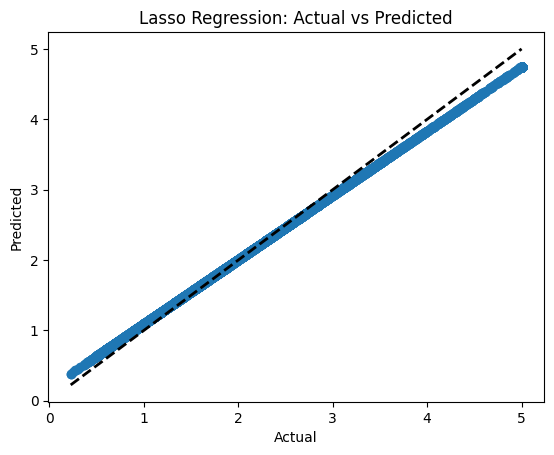

In [12]:
# Lasso regression is a linear model that performs both variable selection and regularization to improve the prediction accuracy and interpretability of the model.

# Key characteristics:
# - Uses L1 regularization (absolute value of coefficients)
# - Can shrink some coefficients to exactly zero (feature selection)
# - Helps prevent overfitting
# - More interpretable than Ridge regression due to feature selection

from sklearn.linear_model import Lasso
lasso_regression_model = Lasso(alpha=0.1)

# Fit the model
lasso_regression_model.fit(X_train, y_train)

# Make predictions
y_pred = lasso_regression_model.predict(X_test)

# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse}")
print(f"R²: {r2}")
print(f"Non-zero coefficients: {lasso_regression_model.coef_[lasso_regression_model.coef_ != 0]}")
print(f"Number of features selected: {sum(lasso_regression_model.coef_ != 0)}")
print(f"Intercept: {lasso_regression_model.intercept_}")
print(f"Number of features with zero coefficients: {sum(lasso_regression_model.coef_ == 0)}")
print(f"Total features: {len(lasso_regression_model.coef_)}")

# Plot feature importance
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Lasso Regression: Actual vs Predicted')
plt.show()



### SVC Regression

MSE: 0.026839960287528965, R2: 0.9615962412420094
SVC Regression Results:
Mean Squared Error: 0.0268
R² Score: 0.9616


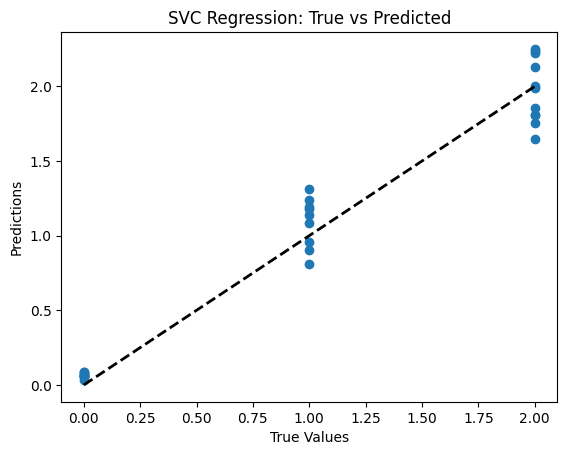

In [16]:
# SVC Regression is a type of Support Vector Machine used for regression tasks.
# It works by finding a hyperplane that best fits the data points while allowing some error.
# The goal is to minimize the error while keeping the margin as large as possible.
# Unlike classification, SVC regression uses epsilon-tube insensitive loss function.
from sklearn import svm 
svm_model = svm.SVR()

#train the model
svm_model.fit(X_train, y_train)

#make predictions
y_pred = svm_model.predict(X_test)

#evaluate the model
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse}, R2: {r2}")
print("SVC Regression Results:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# plot results
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("SVC Regression: True vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()

## Classification

In [14]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)


### Logistic Regression

Accuracy: 0.9667

Confusion Matrix:
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



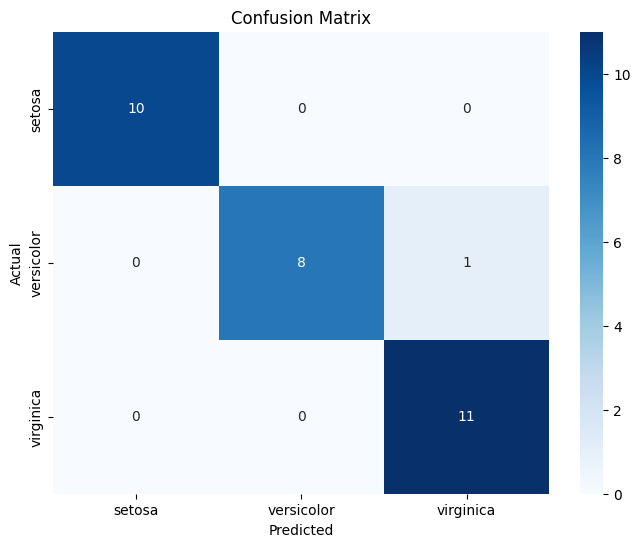

In [19]:
# Logistic Regression is a classification algorithm used for binary and multiclass classification problems.
# It models the probability of a binary outcome using the logistic function.
# The logistic function (sigmoid) maps any real value to a probability between 0 and 1.
# It's commonly used for binary classification tasks like spam detection, medical diagnosis, etc.
# Key assumptions: linear relationship between features and log-odds, independent observations, no multicollinearity.
from sklearn.linear_model import LogisticRegression

logistic_regression_model = LogisticRegression(
    C=0.1,                    # Stronger regularization: Inverse regularization strength (smaller = stronger)
    solver='lbfgs',           # Default solver: optimisation algorithm
    max_iter=200,             # More iterations if needed
    random_state=42,          # For reproducibility
    class_weight='balanced'   # Handle imbalanced classes
)

# Train the model
logistic_regression_model.fit(X_train, y_train)

# Make predictions
y_pred = logistic_regression_model.predict(X_test)


# Evaluate the model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Plot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


### SVM (Support Vector Machine)

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Support vectors shape: (46, 4)
Number of support vectors per class: [ 8 20 18]
Support vectors: [[-1.47393679  1.20365799 -1.56253475 -1.31260282]
 [-0.13307079  2.99237573 -1.27600637 -1.04563275]
 [-0.98634915 -0.13788033 -1.2187007  -1.31260282]
 [-0.86445224  0.53288883 -1.16139502 -0.91214772]
 [-1.7177306  -0.36147005 -1.33331205 -1.31260282]
 [-1.83962751 -0.13788033 -1.50522907 -1.44608785]
 [-1.5958337  -1.70300836 -1.39061772 -1.17911778]
 [-0.49876152  0.75647855 -1.16139502 -1.31260282]
 [ 0.23261993  0.75647855  0.44316389  0.55618763]
 [ 1.08589829  0.08570939  0.55777524  0.4227026 ]

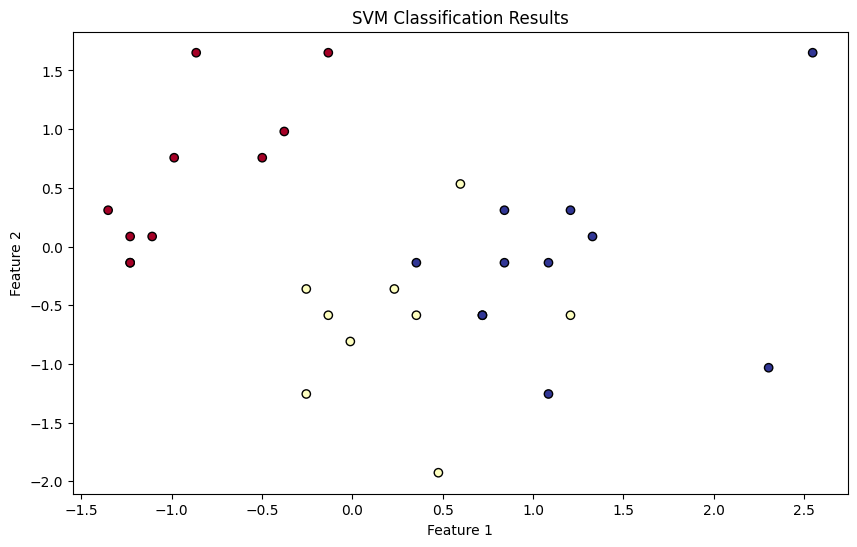

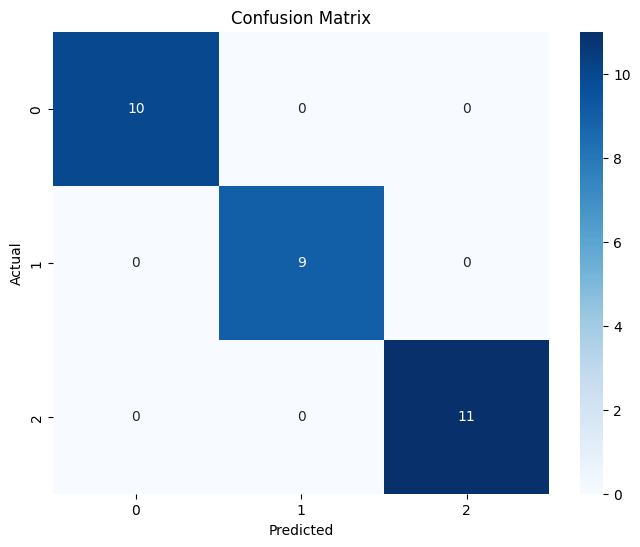

In [20]:
# SVM is a supervised machine learning algorithm used for classification and regression tasks.
# It finds an optimal hyperplane that best separates data points of different classes.
# The hyperplane is chosen to maximize the margin between the classes.
# Support vectors are the data points closest to the hyperplane, defining the margin.
# The goal is to find the hyperplane with the largest possible margin.

from sklearn import svm

svm_model = svm.SVC(
    C=1.0,                     # Paramètre de régularisation (plus C est petit, plus la régularisation est forte)
    kernel='rbf',              # Type de noyau : 'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'
    degree=3,                  # Degré du polynôme pour le noyau 'poly'
    gamma='scale',             # Coefficient pour 'rbf', 'poly', 'sigmoid' : 'scale'=1/(n_features * X.var()), 'auto'=1/n_features
    coef0=0.0,                 # Terme indépendant dans les noyaux 'poly' et 'sigmoid'
    shrinking=True,            # Utilisation de l'heuristique de réduction
    probability=False,         # Active l'estimation des probabilités (plus lent)
    tol=0.001,                 # Tolérance pour le critère d'arrêt
    cache_size=200,            # Taille du cache pour le noyau (en Mo)
    class_weight=None,         # Poids des classes (utile pour les classes déséquilibrées)
    verbose=False,             # Active la sortie verbeuse
    max_iter=-1,               # Nombre maximal d'itérations (-1 = infini)
    decision_function_shape='ovr',  # 'ovr' (un contre reste) ou 'ovo' (un contre un) pour le multi-classe
    break_ties=False,          # Brise les égalités selon les valeurs de decision_function
    random_state=None          # Graine aléatoire pour la reproductibilité
)  # Create an SVM classifier

# Fit the model
svm_model.fit(X_train, y_train)

# Make predictions
y_pred = svm_model.predict(X_test)

# Evaluate the model
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

# Print support vectors
print("Support vectors shape:", svm_model.support_vectors_.shape)
print("Number of support vectors per class:", svm_model.n_support_)
print("Support vectors:", svm_model.support_vectors_)

# Get decision function values
decision_values = svm_model.decision_function(X_test)
print("Decision function shape:", decision_values.shape)
print("First 5 decision function values:", decision_values[:5])

# Get prediction probabilities (if probability=True)
if svm_model.probability:
    probabilities = svm_model.predict_proba(X_test)
    print("Probabilities shape:", probabilities.shape)
    print("First 5 probabilities:", probabilities[:5])

# Plot results
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.RdYlBu, edgecolors='black')
plt.title('SVM Classification Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

#Evaluate model performance
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



### Decision Tree

In [27]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

feature_names = data.feature_names



Accuracy: 0.95


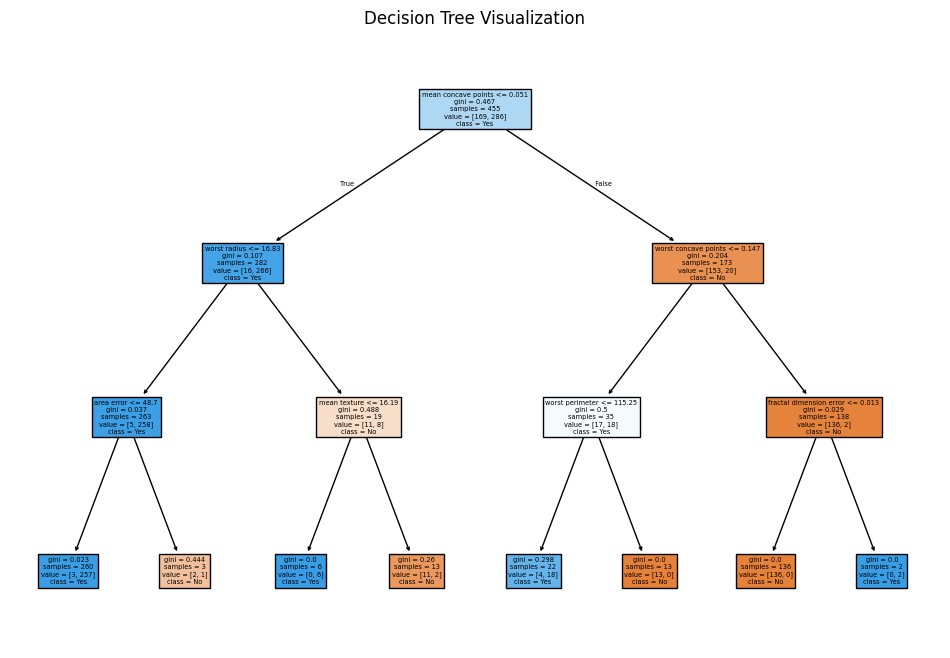


Model Parameters:
Max Depth: 3
Min Samples Split: 5
Number of Classes: 2


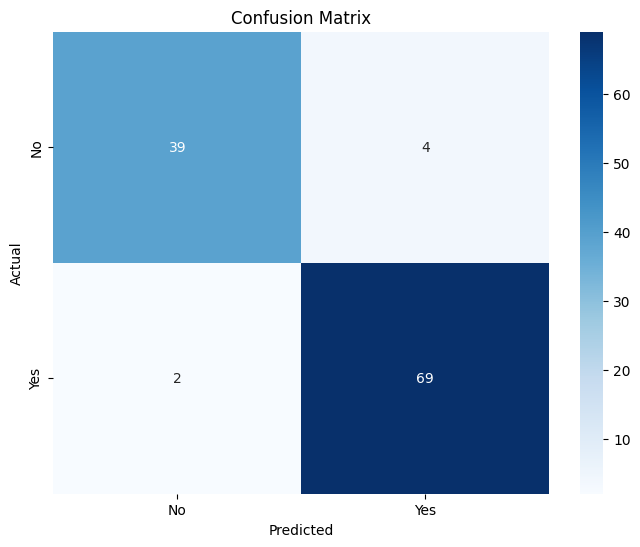


Classification Report:
              precision    recall  f1-score   support

          No       0.95      0.91      0.93        43
         Yes       0.95      0.97      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [31]:
#Decision Tree is a classification algorithm that splits the data based on features to make predictions.
#It creates a tree-like model of decisions based on feature values.

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion='gini',  # or 'entropy': this is the measure of impurity (gini=impurity, entropy=information gain)
    max_depth=3,       # maximum depth of the tree
    min_samples_split=5,  # minimum samples required to split a node
    random_state=42    # for reproducible results
)

# Fit the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred = dt_model.predict(X_test)

# Evaluate the model
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Display feature importance
import pandas as pd
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)



# Visualize the tree (optional)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plot_tree(dt_model, feature_names=feature_names, class_names=['No', 'Yes'], filled=True)
plt.title("Decision Tree Visualization")
plt.show()

# Print model parameters
print("\nModel Parameters:")
print(f"Max Depth: {dt_model.max_depth}")
print(f"Min Samples Split: {dt_model.min_samples_split}")
print(f"Number of Classes: {dt_model.n_classes_}")

# plot the confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print classification report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))




### Random Forests


Top 10 Feature Importances:
 Feature 23: 0.1539
 Feature 27: 0.1447
 Feature 7: 0.1062
 Feature 20: 0.0780
 Feature 6: 0.0680
 Feature 22: 0.0671
 Feature 2: 0.0533
 Feature 0: 0.0487
 Feature 3: 0.0476
 Feature 26: 0.0318
Accuracy: 0.9649122807017544
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



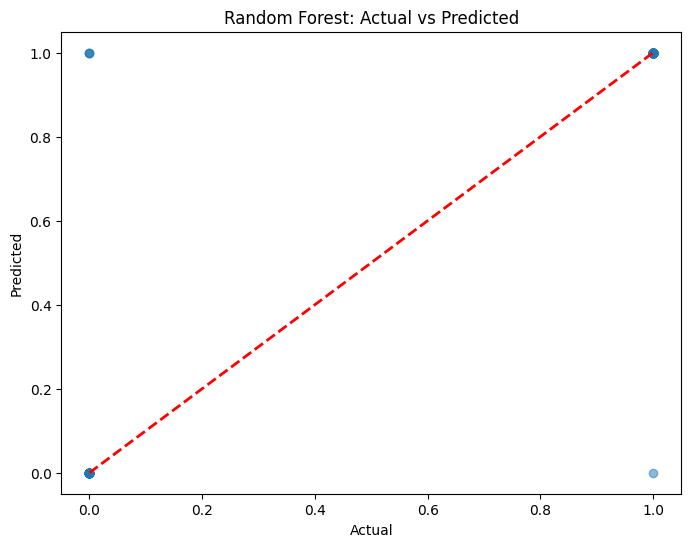

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Best Parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Best Cross-Validation Score: 0.9670
Best Estimator: RandomForestClassifier(max_features='log2', min_samples_split=5,
                       n_estimators=50, random_state=42)


In [33]:
# Random Forest is an ensemble learning method that operates by constructing multiple decision trees during training and outputting the mode of the classes (classification) or mean prediction (regression) of the individual trees.
# It reduces overfitting by averaging multiple models and handles non-linear relationships well.
# Key parameters: n_estimators (number of trees), max_depth (maximum depth of trees), min_samples_split (minimum samples to split a node), random_state (for reproducibility).

from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
n_estimators=100, # Number of trees
criterion='gini', # Splitting criterion
max_depth=None, # Grow trees fully
min_samples_split=2, # Minimum samples to split
min_samples_leaf=1, # Minimum samples in leaf
max_features='sqrt', # sqrt(n_features) considered at each split
bootstrap=True, # Use bootstrap samples
oob_score=True, # Calculate out-of-bag score
n_jobs=-1, # Use all CPU cores
random_state=42

)

# Fit the model
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)



# Feature importance
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
print("\nTop 10 Feature Importances:")
for i in range(min(10, len(importances))):
    print(f" Feature {indices[i]}: {importances[indices[i]]:.4f}")

# Evaluate the model
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))
#plot the evaluation
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest: Actual vs Predicted')
plt.show()

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV
param_grid = {
'n_estimators': [50, 100, 200],
'max_depth': [None, 10, 20, 30],
'min_samples_split': [2, 5, 10],
'min_samples_leaf': [1, 2, 4],
'max_features': ['sqrt', 'log2', None]}  
grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
param_grid,
cv=5,
scoring='accuracy',
n_jobs=-1,
verbose=1
)
grid_search.fit(X_train, y_train)
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")
print(f"Best Estimator: {grid_search.best_estimator_}")








### XGBOOST


In [ ]:
%pip install graphviz


Note: you may need to restart the kernel to use updated packages.


In [36]:
%pip install xgboost


Note: you may need to restart the kernel to use updated packages.


0.21
Accuracy: 0.9561

Top 10 Most Important Features:
                 feature  importance
7    mean concave points    0.257709
27  worst concave points    0.172602
23            worst area    0.103139
22       worst perimeter    0.076875
20          worst radius    0.047865
25     worst compactness    0.045726
26       worst concavity    0.030751
16       concavity error    0.029882
1           mean texture    0.024520
3              mean area    0.022754


/opt/homebrew/lib/python3.11/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


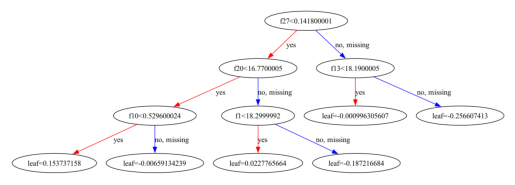


CV Results:
    train-error-mean  train-error-std  train-logloss-mean  train-logloss-std  \
63          0.001648         0.002198            0.022760           0.001724   
64          0.001648         0.002198            0.022379           0.001719   
65          0.001648         0.002198            0.022053           0.001689   
66          0.001648         0.002198            0.021619           0.001647   
67          0.001099         0.002198            0.021259           0.001576   

    test-error-mean  test-error-std  test-logloss-mean  test-logloss-std  
63         0.041758        0.021308           0.117632          0.031630  
64         0.041758        0.020143           0.117303          0.031629  
65         0.041758        0.020143           0.116998          0.031799  
66         0.043956        0.020850           0.116812          0.031690  
67         0.043956        0.020850           0.116674          0.031485  

Scikit-learn API Accuracy: 0.9561


In [51]:
# XGBoost is a gradient boosting framework that uses decision trees as its base learners.
# It is known for its high performance and is widely used in machine learning competitions.
# Commonly used for tabular data prediction tasks, especially in kaggle competitions.
# Popular for structured/tabular data regression and classification problems.
# Often used for feature importance analysis and hyperparameter tuning.
# Excellent for handling missing values and provides built-in regularization.

import xgboost as xgb
import graphviz
print(graphviz.__version__)
params = {
'objective': 'binary:logistic',
'eval_metric': 'logloss', # Binary classification
'learning_rate': 0.1, # Learning rate
'max_depth': 6, # Maximum tree depth
'min_child_weight': 1, # Minimum sum of instance weight
'subsample': 0.8, # Subsample ratio
'colsample_bytree': 0.8, # Feature sampling ratio
'lambda': 1, # L2 regularization
'alpha': 0, # L1 regularization
'seed': 42
}       
xgb_model = xgb.XGBClassifier(**params)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Optional: Check feature importance
import pandas as pd
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)
# Plot tree
from xgboost import plot_tree
import matplotlib.pyplot as plt
# Plot tree using matplotlib
xgb.plot_tree(xgb_model, num_trees=0)
plt.show()
# Cross-validation
cv_results = xgb.cv(
params,
dtrain,
num_boost_round=100,
nfold=5,
metrics={'error', 'logloss'},
early_stopping_rounds=10,
seed=42
)
print(f"\nCV Results:\n{cv_results.tail()}")
# Scikit-learn API
from xgboost import XGBClassifier
xgb_clf = XGBClassifier(
n_estimators=100,
learning_rate=0.1,
max_depth=6,
objective='binary:logistic',
random_state=42
)
xgb_clf.fit(X_train, y_train)
y_pred_sk = xgb_clf.predict(X_test)
print(f"\nScikit-learn API Accuracy: {accuracy_score(y_test, y_pred_sk):.4f}")

# Unsupervised Learning

## Clustering

In [ ]:
# Generate sample data


import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
X, y_true = make_blobs(
n_samples=300,
centers=4,
cluster_std=0.60,
random_state=42
        )
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



### Kmeans Clustering

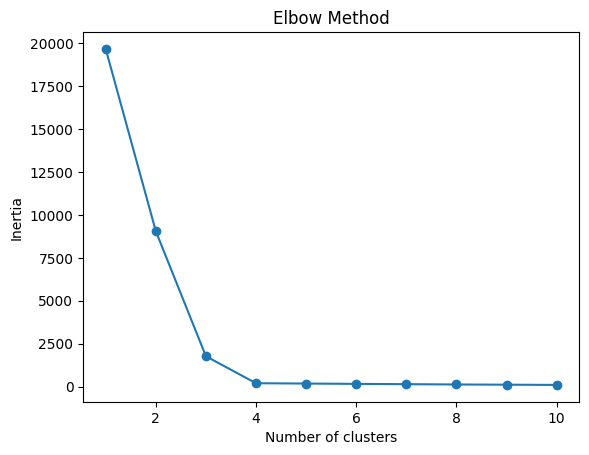

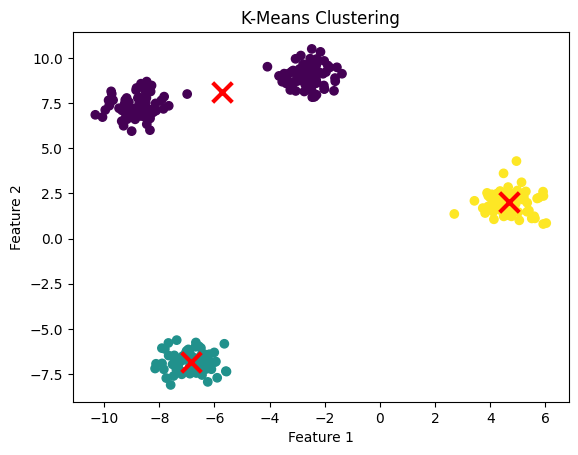

Cluster centers:
[[-5.7198651   8.11855424]
 [-6.85126211 -6.85031833]
 [ 4.68687447  2.01434593]]
Inertia: 1773.736866126526
Cluster 0: 150 samples
Cluster 1: 75 samples
Cluster 2: 75 samples
Silhouette Score: 0.7993
Calinski-Harabasz Score: 1496.8290


In [54]:
# Kmeans clustering is an unsupervised machine learning algorithm used for clustering data into groups based on similarity.
# It partitions data into k clusters where each data point belongs to the cluster with the nearest mean.
# The data should be numerical (ordinal) and normalized for best results.
# Common use cases: customer segmentation, image compression, anomaly detection.
# Steps: Initialize centroids, assign points to nearest centroid, update centroids, repeat until convergence.
# Key parameters: n_clusters (k), init (method to choose initial centroids), max_iter (maximum iterations).

from sklearn.cluster import KMeans


# Elbow method to find optimal k
inertias = []
silhouette_scores = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k,
                    init='k-means++', # the model initialization method - helps avoid poor local minima
                    n_init=10, # number of times the algorithm runs with different centroid seeds
                    max_iter=300, # maximum number of iterations for a single run
                    random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    
import matplotlib.pyplot as plt
plt.plot(range(1, 11), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

kmeans_model = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_pred = kmeans_model.fit_predict(X)

# Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis')
plt.scatter(kmeans_model.cluster_centers_[:, 0], kmeans_model.cluster_centers_[:, 1], c='red', marker='x', s=200, linewidths=3)
plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Print cluster centers
print("Cluster centers:")
print(kmeans_model.cluster_centers_)

# Print inertia (within-cluster sum of squares)
print(f"Inertia: {kmeans_model.inertia_}")

# Print number of samples in each cluster
unique, counts = np.unique(y_pred, return_counts=True)
for i, count in enumerate(counts):
    print(f"Cluster {i}: {count} samples")

# Evaluate the clustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score

silhouette_avg = silhouette_score(X, y_pred)
calinski_harabasz = calinski_harabasz_score(X, y_pred)

print(f"Silhouette Score: {silhouette_avg:.4f}")
print(f"Calinski-Harabasz Score: {calinski_harabasz:.4f}")


### Hierarchical Clustering

Linkage matrix shape: (299, 4)


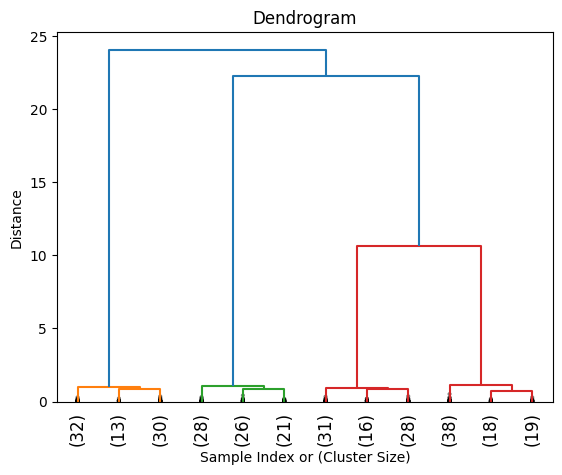

Number of clusters at distance 5: 4
Number of clusters with k=3: 3


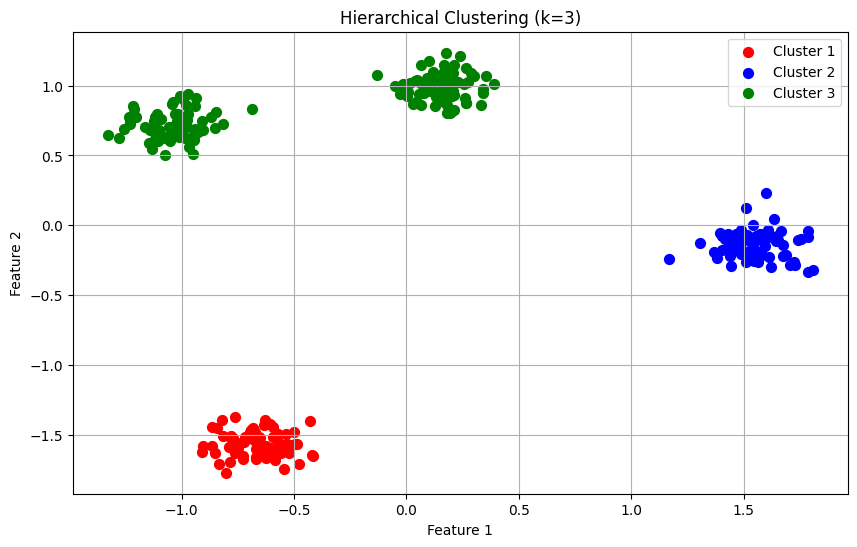

In [56]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster    
# Compute linkage matrix: this matrix encodes the hierarchical clustering
linkage_matrix = linkage(
    X_scaled,
    method='ward',
    metric='euclidean'
)
print("Linkage matrix shape:", linkage_matrix.shape)

from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt
dendrogram(
    linkage_matrix,       # The hierarchical clustering encoded as a linkage matrix
    truncate_mode='lastp',  # How to handle truncation of the dendrogram
    p=12,                 # Number of non-singleton nodes to show when truncating
    show_leaf_counts=True, # Show the number of leaves under each non-leaf node
    leaf_rotation=90,      # Rotate leaf labels by 90 degrees
    leaf_font_size=12,     # Font size for leaf labels
    show_contracted=True   # Draw black dots for contracted branches
)
plt.title("Dendrogram")
plt.xlabel("Sample Index or (Cluster Size)")
plt.ylabel("Distance")
plt.show()
# Determine optimal number of clusters using dendrogram
# Cut dendrogram at certain distance
max_d = 5 # Distance threshold
clusters = fcluster(linkage_matrix, max_d, criterion='distance')
print(f"Number of clusters at distance {max_d}: {len(np.unique(clusters))}")
# Alternative: cut to get k clusters
k = 3
clusters_k = fcluster(linkage_matrix, k, criterion='maxclust')
print(f"Number of clusters with k={k}: {len(np.unique(clusters_k))}")

# Plot clusters
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'purple', 'orange']

for i in range(1, k+1):
    plt.scatter(
    X_scaled[clusters_k == i, 0],
    X_scaled[clusters_k == i, 1],
    s=50, c=colors[i-1], label=f'Cluster {i}')
plt.title(f'Hierarchical Clustering (k={k})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

### DBSCAN (Density-Based Spatial Clustering)

In [58]:
from sklearn.datasets import make_moons, make_circles
from sklearn.preprocessing import StandardScaler
# Generate non-linear data
X1, _ = make_moons(n_samples=300, noise=0.05, random_state=42)
X2, _ = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)
X = np.vstack([X1, X2])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

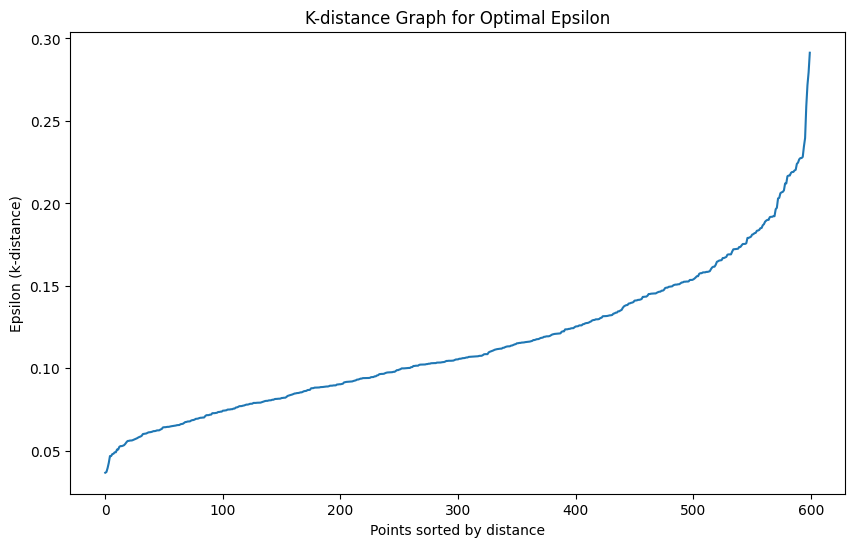

Number of clusters: 1
Number of noise points: 0
Percentage of noise: 0.00%


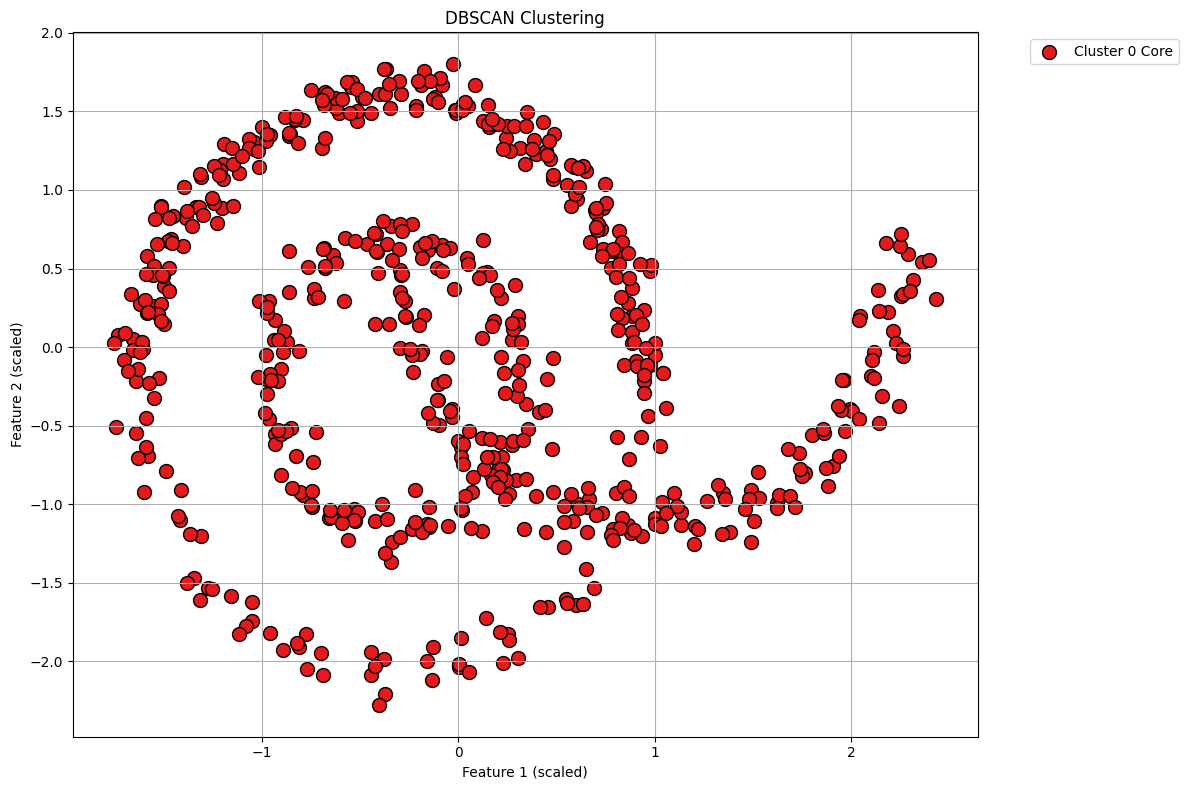

In [63]:
#DBSCAN (Density-Based Spatial Clustering) is a density-based clustering algorithm that groups together points that are closely packed together, marking points that lie alone in low-density regions as outliers.

from sklearn.neighbors import NearestNeighbors
def find_optimal_eps(X, min_samples):
    """
    Find optimal epsilon using knee method.
    Plot k-distance graph and find knee point.
    """
    neigh = NearestNeighbors(n_neighbors=min_samples)
    neigh.fit(X)
    distances, indices = neigh.kneighbors(X)
    # Sort distances
    distances = np.sort(distances[:, -1])
    # Find knee point (maximum curvature)
    # Simplified approach: look for point where slope changes significantly
    # More sophisticated: use Kneedle algorithm
    return distances 
min_samples = 5
distances = find_optimal_eps(X_scaled, min_samples)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(range(len(distances)), distances)
plt.xlabel('Points sorted by distance')
plt.ylabel('Epsilon (k-distance)')
plt.title('K-distance Graph for Optimal Epsilon')
plt.show()

#DBSCAN model
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(
    eps=0.3,            # Maximum distance between two samples
    min_samples=5,      # Minimum samples in a neighborhood
    metric='euclidean', # Distance metric
    algorithm='auto',   # Algorithm for nearest neighbors
    leaf_size=30,       # Leaf size for BallTree/KDTree
    n_jobs=-1           # Use all processors
)

labels = dbscan.fit_predict(X_scaled)
# Analyze results
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")
print(f"Percentage of noise: {100 * n_noise / len(X):.2f}%")
if n_clusters > 1:
    # Silhouette score (excluding noise points)
    mask = labels != -1
    if sum(mask) > 1:
        score = silhouette_score(X_scaled[mask], labels[mask])
        print(f"Silhouette Score (excluding noise): {score:.4f}")
# Visualize clusters
# First, get the core sample indices
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

# Now visualize the clusters
plt.figure(figsize=(12, 8))
unique_labels = set(labels)
colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = 'k'

    class_member_mask = (labels == k)
    
    # Core points in the cluster
    xy = X_scaled[class_member_mask & core_samples_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], 
                edgecolor='k', s=100, label=f'Cluster {k} Core' if k != -1 else 'Noise')
    
    # Border points in the cluster
    xy = X_scaled[class_member_mask & ~core_samples_mask]
    if len(xy) > 0:  # Only plot if there are border points
        plt.scatter(xy[:, 0], xy[:, 1], c=[col], 
                   edgecolor='k', s=40, alpha=0.6, 
                   label=f'Cluster {k} Border' if k != -1 else None)

plt.title('DBSCAN Clustering')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## Dimensionality Reduction

Purpose: Reduce number of features while preserving important information. Examples:
data visualization, noise reduction, speeding up algorithms.

### Principal Component Analysis (PCA)

In [3]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



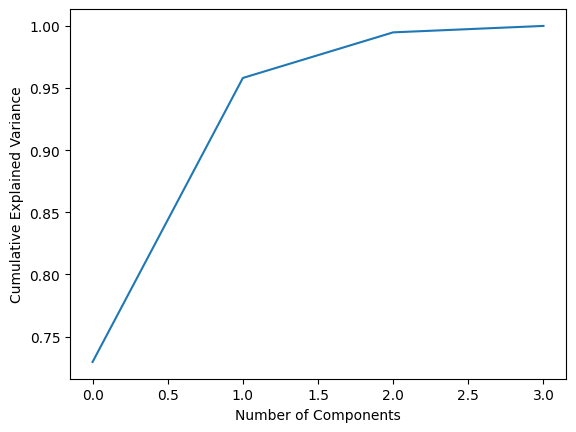

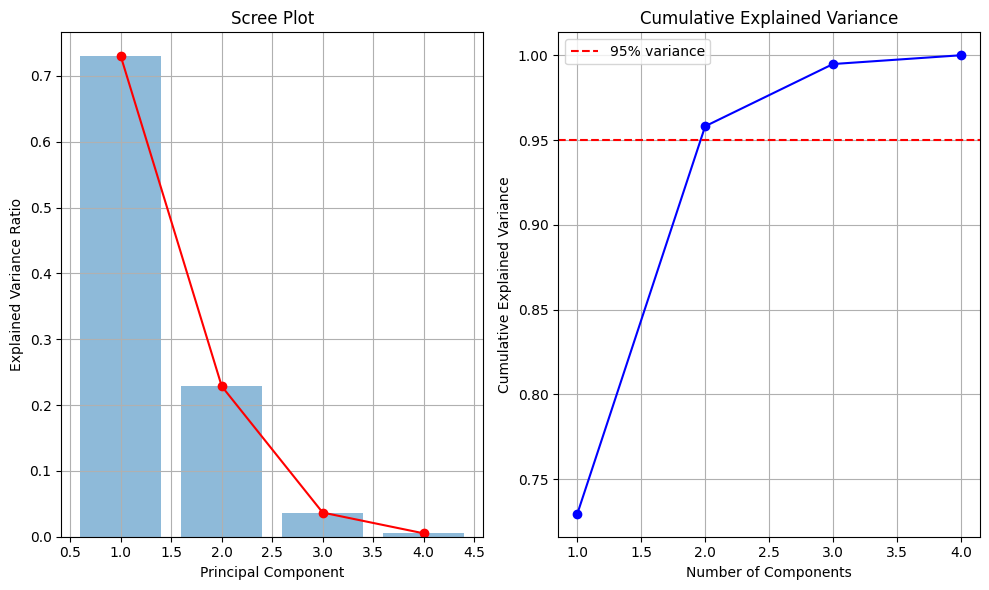

In [5]:
#Principal Component Analysis (PCA) is an algorithm that that capture most variance in data.
#Like finding the best angles to view a 3D object to see its true shape.
'''How PCA Works:
1. Center data (subtract mean)
2. Compute covariance matrix
3. Find eigenvectors (principal components) and eigenvalues (variance explained)
4. Sort by eigenvalues (descending)
5. Project data onto top k eigenvectors '''
from sklearn.decomposition import PCA, KernelPCA
import numpy as np
import matplotlib.pyplot as plt
pca = PCA(n_components=None)

X_pca = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.plot(cumulative_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

# Scree plot
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5)
plt.plot(range(1, len(explained_variance) + 1), explained_variance, 'ro-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()      




Classification Accuracy:
Original features (4): 1.0000
PCA features (2): 0.9000
Error with kernel poly: Matrix is singular.


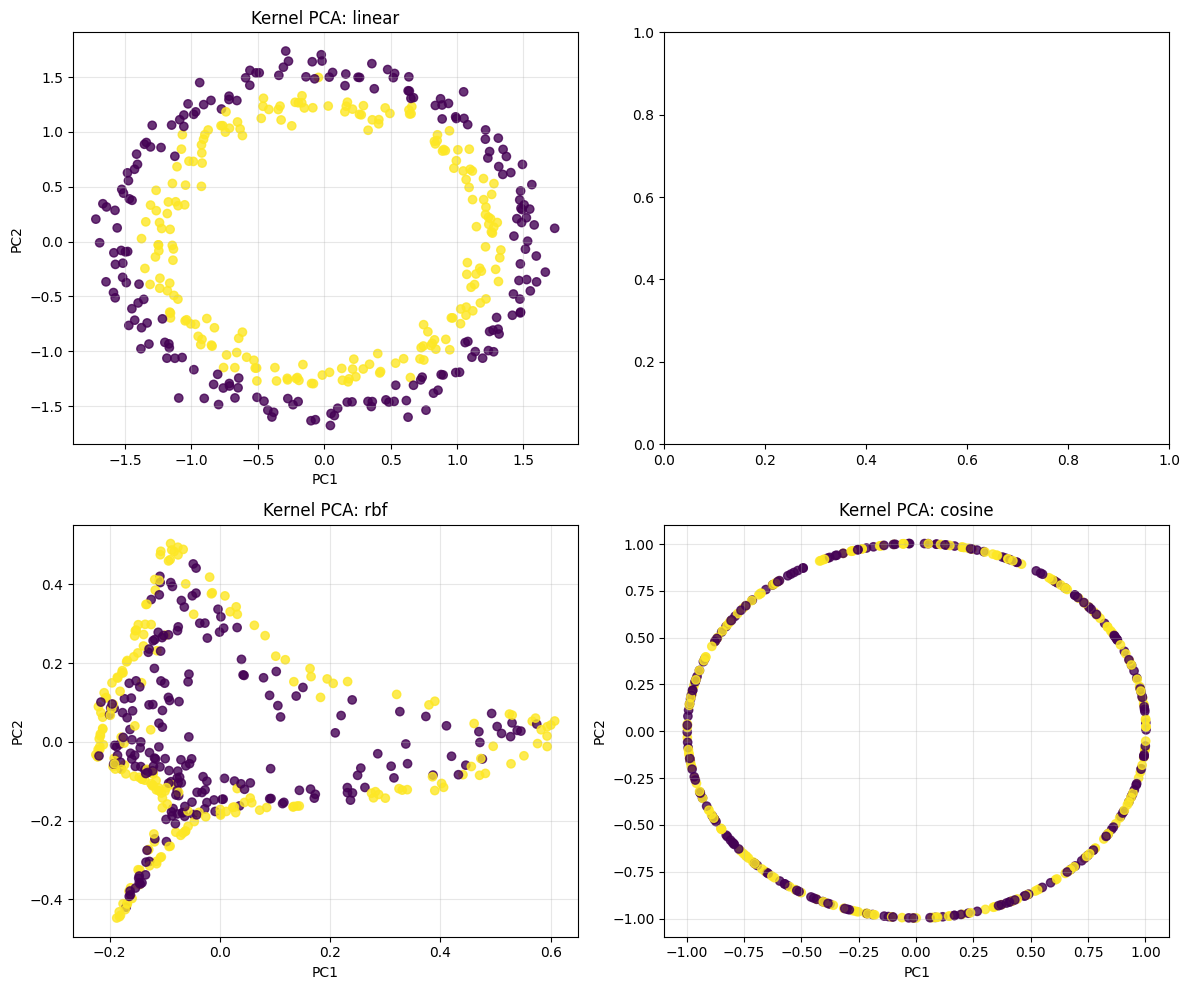

In [6]:
# First, let's import all necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles

# Assuming X_scaled and y are already defined from your previous code
# If not, you'll need to define them first

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, 
    y, 
    test_size=0.2, 
    random_state=42
)

# Train classifier on original features
clf_original = LogisticRegression(random_state=42, max_iter=1000)  # Added max_iter
clf_original.fit(X_train, y_train)
y_pred_original = clf_original.predict(X_test)
acc_original = accuracy_score(y_test, y_pred_original)

# Train classifier on PCA features
pca_clf = PCA(n_components=2)
X_train_pca = pca_clf.fit_transform(X_train)
X_test_pca = pca_clf.transform(X_test)
clf_pca = LogisticRegression(random_state=42, max_iter=1000)  # Added max_iter
clf_pca.fit(X_train_pca, y_train)
y_pred_pca = clf_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print(f"\nClassification Accuracy:")
print(f"Original features ({X_train.shape[1]}): {acc_original:.4f}")
print(f"PCA features ({X_train_pca.shape[1]}): {acc_pca:.4f}")

# Kernel PCA for non-linear data
X_circles, y_circles = make_circles(n_samples=400, noise=0.05, random_state=42)
X_circles_scaled = StandardScaler().fit_transform(X_circles)

# Apply different kernel PCAs
kernels = ['linear', 'poly', 'rbf', 'cosine']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, kernel in enumerate(kernels):
    row, col = divmod(idx, 2)
    ax = axes[row, col]
    
    try:
        kpca = KernelPCA(
            n_components=2, 
            kernel=kernel, 
            gamma=10,
            fit_inverse_transform=True
        )
        X_kpca = kpca.fit_transform(X_circles_scaled)
        
        scatter = ax.scatter(
            X_kpca[:, 0], 
            X_kpca[:, 1], 
            c=y_circles, 
            cmap='viridis', 
            alpha=0.8
        )
        ax.set_title(f'Kernel PCA: {kernel}')
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.grid(True, alpha=0.3)
        
    except Exception as e:
        print(f"Error with kernel {kernel}: {str(e)}")
        continue

plt.tight_layout()
plt.show()

In [8]:
# PCA for feature extraction
import pandas as pd
print("\nPCA Components (Loadings):")
components_df = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)  # Added missing closing parenthesis here
print(components_df.round(3))


PCA Components (Loadings):
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
PC1              0.521            -0.269              0.580             0.565
PC2              0.377             0.923              0.024             0.067
PC3              0.720            -0.244             -0.142            -0.634
PC4             -0.261             0.124              0.801            -0.524
